# Timepoint Classification Results
## Read tensorboard file

In [1]:
import os

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from collections import Counter

from tensorboard.backend.event_processing import event_accumulator
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score

In [2]:
%matplotlib inline

In [3]:
%cd ..

/common/wut4/workspace/OCT


In [4]:
result_dir = './results/20240703-160504'

In [5]:
train_df = pd.read_csv(os.path.join(result_dir, 'train_df.csv'))
valid_df = pd.read_csv(os.path.join(result_dir, 'valid_df.csv'))
test_df = pd.read_csv(os.path.join(result_dir, 'test_df.csv'))

In [6]:
train_df.head()

,path,date,case,ID,pos
0,./data/OCT-Tiff/P120_2_8-2024/AI005_OD_V_3x3_0...,P120,AI005_OD_V_3x3_0_0000094 2-8-2024,AI005,1
1,./data/OCT-Tiff/P120_2_8-2024/AI005_OD_V_3x3_0...,P120,AI005_OD_V_3x3_0_0000094 2-8-2024,AI005,2
2,./data/OCT-Tiff/P120_2_8-2024/AI005_OD_V_3x3_0...,P120,AI005_OD_V_3x3_0_0000094 2-8-2024,AI005,3
3,./data/OCT-Tiff/P120_2_8-2024/AI005_OD_V_3x3_0...,P120,AI005_OD_V_3x3_0_0000094 2-8-2024,AI005,4
4,./data/OCT-Tiff/P120_2_8-2024/AI005_OD_V_3x3_0...,P120,AI005_OD_V_3x3_0_0000094 2-8-2024,AI005,5


In [7]:
print(f"total image: {len(train_df)}")
print(f"total ID: {len(set(train_df['ID']))}")
print(f"total case: {len(set(train_df['case']))}")
Counter(train_df['date'])

total image: 41400
total ID: 21
total case: 138


Counter({'P20': 11400,
         'P40': 9000,
         'P60': 7800,
         'P90': 6600,
         'P120': 4200,
         'P150': 1200,
         'P158': 1200})

In [8]:
print(f"total image: {len(valid_df)}")
print(f"total ID: {len(set(valid_df['ID']))}")
print(f"total case: {len(set(valid_df['case']))}")
Counter(valid_df['date'])

total image: 10170
total ID: 7
total case: 34


Counter({'P20': 3570, 'P40': 3300, 'P60': 2400, 'P150': 600, 'P90': 300})

In [9]:
print(f"total image: {len(test_df)}")
print(f"total ID: {len(set(test_df['ID']))}")
print(f"total case: {len(set(test_df['case']))}")
Counter(test_df['date'])

total image: 10500
total ID: 7
total case: 35


Counter({'P20': 4200, 'P40': 2700, 'P60': 1800, 'P90': 1200, 'P120': 600})

In [10]:
# Load tf files
tb_file = [item for item in os.listdir(os.path.join(result_dir, 'lightning_logs', 'version_0')) if item.startswith('events')]
assert len(tb_file) == 1
tb_path = os.path.join(result_dir, 'lightning_logs', 'version_0', tb_file[0])
assert os.path.isfile(tb_path)

In [11]:
ea = event_accumulator.EventAccumulator(tb_path,
            size_guidance={ # see below regarding this argument
            event_accumulator.COMPRESSED_HISTOGRAMS: 500,
            event_accumulator.IMAGES: 4,
            event_accumulator.AUDIO: 4,
            event_accumulator.SCALARS: 0,
            event_accumulator.HISTOGRAMS: 1,
        })

ea.Reload() # loads events from file

In [12]:
val_loss = [item.value for item in ea.Scalars('val_loss')]
print(f"val loss length: {len(val_loss)}")
train_loss = [item.value for item in ea.Scalars('train_loss_step')]
print(f"train loss length: {len(train_loss)}")

# moving average on train loss
train_loss = np.array(train_loss)
final_size = len(val_loss)
step = len(train_loss) // final_size
moving_averages = [np.mean(train_loss[i:i+step]) for i in range(0, len(train_loss), step)]


val loss length: 41
train loss length: 219


In [13]:
data = {
    'trained_step': [i * 50 for i in range(len(moving_averages))],
    'training_loss': moving_averages,
    'validation_loss': val_loss
}

df = pd.DataFrame.from_dict(data, orient='index').transpose()
df.to_csv(os.path.join(result_dir, 'loss_data.csv'), index=False) 

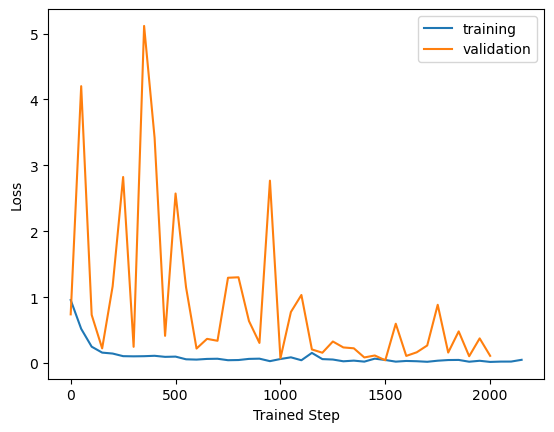

In [14]:
# Plot train/valid loss
plt.plot([item*50 for item in range(len(moving_averages))], moving_averages, label='training')
plt.plot([item*50 for item in range(len(val_loss))], val_loss, label='validation')
plt.xlabel('Trained Step')
plt.ylabel('Loss')
plt.legend()
plt.savefig(os.path.join(result_dir, 'loss_plot.png'))

output_path = os.path.join(result_dir, 'loss_plot.tiff')
plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight', pil_kwargs={"rgb_mode": "RGB"})

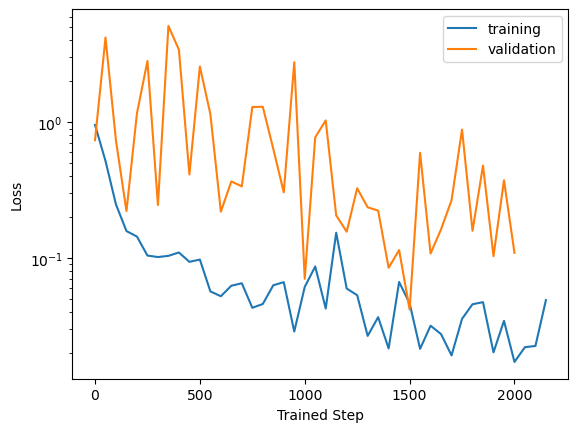

In [15]:
# Plot train/valid loss with log scale
plt.plot([item*50 for item in range(len(moving_averages))], moving_averages, label='training')
plt.plot([item*50 for item in range(len(val_loss))], val_loss, label='validation')
plt.xlabel('Trained Step')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.savefig(os.path.join(result_dir, 'loss_plot_log.png'))

output_path = os.path.join(result_dir, 'loss_plot_log.tiff')
plt.savefig(output_path, format='tiff', dpi=300, bbox_inches='tight', pil_kwargs={"rgb_mode": "RGB"})

## Evaluation on test data

In [16]:
# Load test dataframe
df = pd.read_csv(os.path.join(result_dir, 'test_df.csv'))

In [17]:
class2index = {
    'P20': 0,
    'P40': 1, 
    'P60': 2,
    'P90': 3,
    'P120': 4,
    'P150': 4,
    'P158': 4
}

In [18]:
# Merge prediction

df['gt'] = df['date'].map(class2index)

# Load prediction
gt = np.load(os.path.join(result_dir, 'gt.npy'))
pred = np.load(os.path.join(result_dir, 'pred.npy'))
pred = np.argmax(pred, axis=1)

df['load_gt'] = gt
df['pd'] = pred

assert df['gt'].equals(df['load_gt'])


In [19]:
df.head()

,path,date,case,ID,pos,gt,load_gt,pd
0,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,1,4,4,4
1,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,2,4,4,4
2,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,3,4,4,4
3,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,4,4,4,4
4,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,5,4,4,4


In [20]:
df.to_csv(os.path.join(result_dir, 'test_df_all.csv'), index=False)

In [21]:
cf_matrix = confusion_matrix(gt, pred)

In [22]:
acc = np.sum(gt==pred) / len(gt)
f1 = f1_score(gt, pred, average='macro')

print(f"accuracy: {acc*100:.2f}%")
print(f"F1 score: {f1*100:.2f}%")

accuracy: 95.95%
F1 score: 94.93%


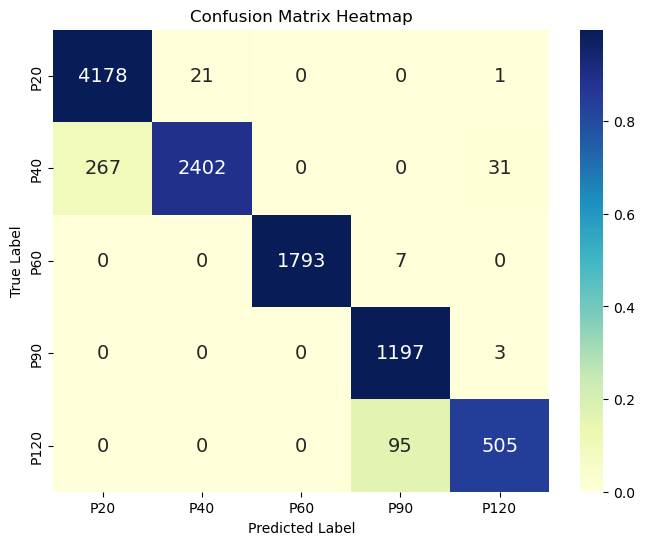

In [23]:
conf_df = pd.DataFrame(cf_matrix, index=['P20', 'P40', 'P60', 'P90', 'P120'], columns=['P20', 'P40', 'P60', 'P90', 'P120'])
accuracy_matrix = cf_matrix.astype('float') / cf_matrix.sum(axis=1)[:, np.newaxis]
accuracy_df = pd.DataFrame(accuracy_matrix, index=['P20', 'P40', 'P60', 'P90', 'P120'], columns=['P20', 'P40', 'P60', 'P90', 'P120'])

plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_df, annot=conf_df, fmt="d", cmap="YlGnBu", annot_kws={"size": 14})
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(os.path.join(result_dir, 'conf_heatmap.png'))

## Load survey data (subset)

In [24]:
survey_df = pd.read_excel('./data/test_survey_df.xlsx')

In [25]:
survey_df.head()

,path,date,case,ID,pos
0,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,5
1,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,13
2,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,14
3,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,23
4,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,26


In [26]:
merged_df = survey_df.merge(df[['path', 'gt', 'pd']], on='path', how='left')

In [27]:
merged_df.head()

,path,date,case,ID,pos,gt,pd
0,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,5,4,4
1,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,13,4,4
2,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,14,4,4
3,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,23,4,3
4,./data/OCT-Tiff/P120_2_8-2024/AI027_OD_V_3x3_0...,P120,AI027_OD_V_3x3_0_0000072_2_8_2024,AI027,26,4,4


In [28]:
merged_df.to_csv(os.path.join(result_dir, 'test_survery_df_w_AIpred.csv'), index=False)

In [29]:
cf_matrix = confusion_matrix(merged_df['gt'], merged_df['pd'])

In [30]:
cf_matrix

array([[ 99,   1,   0,   0,   0],
       [ 14,  84,   0,   0,   2],
       [  0,   0, 100,   0,   0],
       [  0,   0,   0,  99,   1],
       [  0,   0,   0,  13,  87]])

In [31]:
acc = np.sum(merged_df['gt']==merged_df['pd']) / len(merged_df['gt'])
f1 = f1_score(merged_df['gt'], merged_df['pd'], average='macro')

print(f"accuracy: {acc*100:.2f}%")
print(f"F1 score: {f1*100:.2f}%")

accuracy: 93.80%
F1 score: 93.75%


## Case-based Voting Prediction

In [32]:
case_df = df.groupby('case').agg({
    'gt': lambda x: x.mode()[0], 
    'pd': lambda x: x.mode()[0],
    'path': 'size' 
}).rename(columns={'path': 'Total Images'}).reset_index()

pd_counts = df.groupby('case')['pd'].apply(lambda x: x.value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)).unstack().reset_index()

# Merge the counts with the original grouped data
case_df = case_df.merge(pd_counts, on='case')

In [33]:
case_df = case_df.rename(columns={
    'gt': 'Ground True',
    'pd': 'Voting Prediction',
    0: 'P20',
    1: 'P40',
    2: 'P60',
    3: 'P90',
    4: '>=P120'
})

In [34]:
acc = np.sum(case_df['Ground True']==case_df['Voting Prediction']) / len(case_df['Ground True'])
f1 = f1_score(case_df['Ground True'], case_df['Voting Prediction'], average='macro')

print(f"accuracy: {acc*100:.2f}%")
print(f"F1 score: {f1*100:.2f}%")

accuracy: 97.14%
F1 score: 98.13%


In [35]:
case_df.to_csv(os.path.join(result_dir, 'test_case_df.csv'), index=False)